In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import sklearn
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from rdkit.Chem import Descriptors
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, MinMaxScaler, MaxAbsScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor 
from sklearn.svm import SVR
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, ShuffleSplit, KFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, f1_score, roc_auc_score
import pickle

In [2]:
df = pd.read_csv('dataset_for_cellulose_solubility_ML_model_water_content_less_1%.csv')
smis = list(df.loc[:, 'smiles'])
cation = list(df.loc[:, 'cation'])
anion = list(df.loc[:, 'anion'])
Ts = list(df.loc[:, 'T'])
Crystal = list(df.loc[:, 'cellulose_crystal'])
Crystal_avicel = []
Crystal_MCC = []
Crystal_cellulose = []
for item in Crystal:
    if item == 'Avicel':
        Crystal_avicel.append(1)
        Crystal_MCC.append(0)
        Crystal_cellulose.append(0)
    
    elif item == 'MCC':
        Crystal_avicel.append(0)
        Crystal_MCC.append(1)
        Crystal_cellulose.append(0)
        
    elif item == 'cellulose':
        Crystal_avicel.append(0)
        Crystal_MCC.append(0)
        Crystal_cellulose.append(1)
        
heating_time = list(df.loc[:,'heating_time'])
Ys = list(df.loc[:, 'solv'])

In [3]:
def getMolDescriptors(smi):
    mol = Chem.MolFromSmiles(smi)
    res = []
    for nm, fn in Descriptors._descList:
        res.append(fn(mol))
    return res

def smiles_to_MACCS(smi): 
    mol = Chem.MolFromSmiles(smi)
    fp = AllChem.GetMACCSKeysFingerprint(mol)
    fp = np.array(fp, float)
    return fp
Des_cation = np.array([getMolDescriptors(c) for c in cation])
Des_anion = np.array([getMolDescriptors(a) for a in anion])
fp_anion = np.array([smiles_to_MACCS(a) for a in anion])
fp_cation = np.array([smiles_to_MACCS(c) for c in cation])
X = np.c_[fp_cation, Des_cation, fp_anion, Des_anion, Ts, heating_time, Crystal_avicel, Crystal_MCC, Crystal_cellulose]
Y = np.array(Ys).reshape(len(Ys), 1)

In [4]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.Q1_ = np.percentile(X, 25, axis=0)
        self.Q3_ = np.percentile(X, 75, axis=0)
        self.IQR_ = self.Q3_ - self.Q1_
        return self
    
    def transform(self, X):
        lower = self.Q1_ - 1.5 * self.IQR_
        upper = self.Q3_ + 1.5 * self.IQR_
        return np.clip(X, lower, upper)

class ZScoreClipper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=3):
        self.threshold = threshold
    
    def fit(self, X, y=None):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        
        self.std_[self.std_ == 0] = 1e-8
        
        return self
    
    def transform(self, X):
        z_scores = (X - self.mean_) / self.std_
        
        return np.where(
            np.abs(z_scores) <= self.threshold,
            X,
            self.mean_ + self.threshold * self.std_ * np.sign(z_scores)
        )


def prepareData(dfEmployee, solv, typeImputer, typeOutlier, typeScaler):
    
    # 1. Séparation et copie propre
    X = dfEmployee.copy()
    Y = solv.copy()
    
    # Sécurité absolue : On s'assure que TOUS les noms de colonnes sont des chaînes de caractères
    X.columns = X.columns.astype(str)
    
    # Identification dynamique et robuste des colonnes présentes dans X
    num_cols_all = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    # Une colonne est binaire uniquement si elle a 2 valeurs ET qu'elle est toujours dans X
    binary_cols = [col for col in num_cols_all if X[col].nunique() == 2]
    
    # Les colonnes numériques sont celles qui ne sont pas binaires
    num_cols = [col for col in num_cols_all if col not in binary_cols]
    
    # Les colonnes catégorielles
    cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
    
    # 2. Définition des pipelines
    num_pipeline = Pipeline([
        ('imputer', typeImputer),
        ('outlier_clipper', typeOutlier),
        ('scaler', typeScaler)
    ])
    
    bin_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="most_frequent")) 
    ])
    
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="most_frequent")),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_cols),
        ("bin", bin_pipeline, binary_cols),
        ("cat", cat_pipeline, cat_cols),
    ])
    
    # 3. Transformation de X uniquement
    X_prepared = full_pipeline.fit_transform(X)

    # Reconstruction dynamique des noms de colonnes pour le DataFrame final
    if cat_cols:
        cat_encoder = full_pipeline.named_transformers_["cat"]["encoder"]
        cat_columns = cat_encoder.get_feature_names_out(cat_cols).tolist()
    else:
        cat_columns = []
        
    all_columns = num_cols + binary_cols + cat_columns
    
    X_prepared_df = pd.DataFrame(
        X_prepared,
        columns=all_columns,
        index=X.index
    )
    
    # 5. Assemblage du DataFrame de sortie complet
    cleanDf = X_prepared_df.copy()
    cleanDf['solv'] = Y
    
    return X_prepared_df, Y, cleanDf, full_pipeline



imputerList = [
    SimpleImputer(strategy="mean"),
    SimpleImputer(strategy="median"),
    SimpleImputer(strategy="most_frequent"),
    SimpleImputer(strategy="constant", fill_value=0),
    KNNImputer(n_neighbors=5)
]

outlierList = [
    IQRClipper(),
    ZScoreClipper()
]

normalizeList = [
    StandardScaler(),
    RobustScaler(),
    MinMaxScaler(),
    MaxAbsScaler()
]

In [5]:
dataCellulose = pd.DataFrame(X)

#print(dataCellulose)

columnToremove = []
for column in dataCellulose.columns:
    firstvalue = None
    isAnyDifference = False
    for j in dataCellulose[column].values:
        if(firstvalue == None):
            firstvalue = j
        if(j != firstvalue):
            isAnyDifference = True
            
    if(isAnyDifference == False):
            columnToremove.append(column)
            #print("Colonne à supprimer : ", column)

print("Colonnes à supprimer : ", columnToremove)
            
#dataCellulose = dataCellulose.drop(columns=columnToremove)

#colonnes_conservees = dataCellulose.columns.tolist()
#print(colonnes_conservees)

Colonnes à supprimer :  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 20, 21, 22, 23, 25, 26, 27, 31, 32, 33, 35, 36, 37, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 53, 55, 56, 58, 59, 60, 61, 62, 63, 64, 66, 67, 68, 69, 73, 76, 81, 87, 88, 92, 103, 106, 107, 134, 135, 136, 145, 154, 166, 177, 219, 230, 236, 239, 247, 249, 252, 253, 263, 292, 295, 296, 299, 300, 301, 302, 303, 304, 305, 306, 314, 315, 316, 317, 319, 321, 323, 324, 325, 327, 329, 330, 331, 332, 334, 335, 336, 337, 338, 340, 341, 342, 343, 344, 345, 346, 349, 350, 351, 352, 353, 354, 355, 357, 358, 359, 360, 362, 363, 364, 367, 368, 369, 370, 371, 372, 373, 374, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 396, 397, 398, 399, 401, 402, 403, 405, 406, 407, 411, 412, 413, 414, 415, 420, 422, 424, 426, 427, 433, 434, 436, 439, 440, 441, 445, 448, 452, 453, 455, 462, 464, 496, 499, 510, 512, 522, 543, 554, 595, 613, 624, 626, 630, 653, 663, 672, 681, 682

In [6]:

#sns.heatmap(dataCellulose, annot=True, cmap="YlGnBu", linewidths=0.5)
#plt.show()

#X = dataCellulose.drop('solv', axis=1).values
#Y = dataCellulose['solv'].values

X, y, dfCelluloseClean, full_pipeline = prepareData(dataCellulose, Y, imputerList[1], outlierList[0], normalizeList[1])

print(y)


[[ 8.        ]
 [ 5.75      ]
 [ 9.08503815]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 1.85883514]
 [ 1.        ]
 [ 9.47780819]
 [16.        ]
 [ 8.5       ]
 [15.5       ]
 [ 0.        ]
 [ 0.        ]
 [13.        ]
 [ 0.        ]
 [ 1.52284264]
 [ 0.        ]
 [ 0.        ]
 [21.98723725]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.5       ]
 [ 0.        ]
 [ 0.        ]
 [ 3.17231217]
 [ 0.        ]
 [ 2.13765603]
 [ 6.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 6.05      ]
 [15.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.53441401]
 [ 1.01010101]
 [ 0.        ]
 [15.        ]
 [21.        ]
 [ 1.49125469]
 [10.9       ]
 [14.        ]
 [17.        ]
 [ 0.        ]
 [18.5       ]
 [ 0.5       ]
 [ 4.71204188]
 [ 0.        ]
 [ 0.        ]
 [16.12032708]
 [ 0.46470879]
 [ 0.        ]
 [ 1.01010101]
 [ 4.9       ]
 [10.        ]
 [ 7.52688172]
 [ 2.        ]
 [ 0.        ]
 [ 0.        ]
 [15.        ]
 [24.48578693]
 [ 0.     

In [7]:
corr = dfCelluloseClean.corr(numeric_only=True)
corr_solv = corr['solv'].sort_values(ascending=False)

corr_solv_clean = corr_solv.dropna()

print("--- Top corrélations (sans les NaN) ---")
print(corr_solv_clean)

"""
plt.figure(figsize=(12, 8))
sns.heatmap(dfCelluloseClean.corr(), annot=True, cmap='coolwarm')
plt.title('Matrice de Corrélation')
plt.show()
"""

--- Top corrélations (sans les NaN) ---
solv    1.000000
215     0.517624
183     0.503121
259     0.489810
232     0.484226
          ...   
30     -0.375397
112    -0.375397
366    -0.378836
138    -0.420444
272    -0.426080
Name: solv, Length: 411, dtype: float64


"\nplt.figure(figsize=(12, 8))\nsns.heatmap(dfCelluloseClean.corr(), annot=True, cmap='coolwarm')\nplt.title('Matrice de Corrélation')\nplt.show()\n"

In [8]:
#X = sm.add_constant(X)
#model = sm.OLS(y, X).fit()
#print(model.summary())


In [9]:
grids = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {
            "fit_intercept": [True, False]
        }
    },
    
    "RidgeRegression": {
        "model": Ridge(random_state=42),
        "params": {
            "alpha": [0.1, 1.0, 10.0, 100.0],
            "solver": ["auto", "cholesky", "sparse_cg"]
        }
    },
    
    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            "n_neighbors": [3, 5, 7, 11, 15],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"]
        }
    },
    
    "DecisionTree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "criterion": ["squared_error", "absolute_error"],
            "max_depth": [4, 6, 8, 12, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
            "max_features": ["sqrt", "log2"]
        }
    },

    "SVR": {
        "model": SVR(),
        "params": {
            "C": [0.1, 1, 10, 100],
            "kernel": ["rbf", "linear"],
            "epsilon": [0.01, 0.1, 0.2] 
        }
    },
    
    "BayesianRidge": {
        "model": BayesianRidge(),
        "params": {
            "alpha_1": [1e-6, 1e-5, 1e-4],
            "lambda_1": [1e-6, 1e-5, 1e-4]
        }
    },
}

from sklearn.svm import SVR
import numpy as np

"""
"C": [0.1, 1, 10, 100],
"kernel": ["rbf", "linear", "poly"],
"epsilon": [0.01, 0.1, 0.2] 

"C": [0.01, 0.1, 1, 10, 100, 1000],
"epsilon": [0.001, 0.01, 0.05, 0.1, 0.2, 0.5],
"kernel": ["linear", "rbf"],
"degree": [2, 3],
"gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1]
"""
grid2 = {
    "SVR": {
        "model": SVR(),
        "params": {
            "C": [1600],
            "kernel": ["rbf"],
            "degree": [2],
            "epsilon": [0.3],
            "gamma": [0.01]
        }
    }
}

c:\Users\marct\miniconda3\envs\IonGen\lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



================== SVR ==================
Meilleurs paramètres : {'C': 1600, 'degree': 2, 'epsilon': 0.3, 'gamma': 0.01, 'kernel': 'rbf'}
Scoring (r2) moyen (CV) : 0.8024
Performance sur le Test Set -> R² : 0.905 | RMSE : 2.294


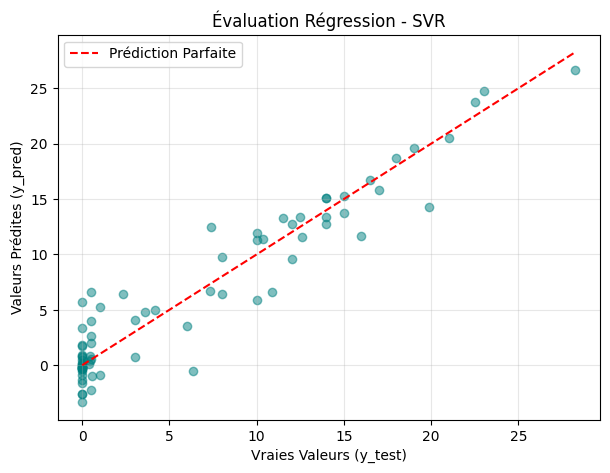

In [10]:
metrics_map = {
    "R2-Score": "r2",
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error"
}

cv_strategies = {
    "K-Fold": KFold(n_splits=5, shuffle=True, random_state=42),
    "Shuffle Split": ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def trainTestModels(grids, scoringType, cvOption, X_train, y_train, X_test, y_test):
    best_models = {}
    
    for name, config in grids.items():
        grid = GridSearchCV(
            config["model"],
            config["params"],
            cv=cvOption,
            scoring=scoringType,
            n_jobs=-1
        )
        
        grid.fit(X_train, y_train)
        
        best_cv_score = grid.best_score_ 
        best_model = grid.best_estimator_
        
        print(f"\n================== {name} ==================")
        print(f"Meilleurs paramètres : {grid.best_params_}")
        print(f"Scoring ({scoringType}) moyen (CV) : {best_cv_score:.4f}")
        
        # Prédictions
        y_pred = best_model.predict(X_test)
        
        # Calcul des métriques de test réelles
        r2_val = r2_score(y_test, y_pred)
        rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
        
        print(f"Performance sur le Test Set -> R² : {r2_val:.3f} | RMSE : {rmse_val:.3f}")
        
        best_models[name] = {"Model": best_model, "CV_Score": best_cv_score, "R2_Test": r2_val}
        
        # Graphique d'évaluation pour la régression : Réel vs Prédit
        plt.figure(figsize=(7, 5))
        plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
        
        # Ligne diagonale idéale
        ideal_line = [min(y_test), max(y_test)]
        plt.plot(ideal_line, ideal_line, '--', color='red', label='Prédiction Parfaite')
        
        plt.xlabel("Vraies Valeurs (y_test)")
        plt.ylabel("Valeurs Prédites (y_pred)")
        plt.title(f"Évaluation Régression - {name}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    return best_models

best_models = trainTestModels(grid2, metrics_map["R2-Score"], cv_strategies["K-Fold"], X_train, y_train, X_test, y_test)

In [11]:
model = best_models["SVR"]["Model"]

filename = "model_cellullose_marc.pickle"

pickle.dump(model, open(filename, "wb"))

In [12]:
MIN_TEMPERATURE = 20
MAX_TEMPERATURE = 200
MIN_HEATING_TIME = 0.5
MAX_HEATING_TIME = 96
LISTE_CELLULOSE_CRYSTALS = ['Avicel', 'MCC', 'cellulose']

liste_temps = np.around(np.arange(MIN_HEATING_TIME, MAX_HEATING_TIME), 1)
liste_temp = np.arange(MIN_TEMPERATURE, MAX_TEMPERATURE + 1)

scenarios_physiques = []
metadonnees = []

for crystal in LISTE_CELLULOSE_CRYSTALS:
    crystal_avicel = 1.0 if crystal == 'Avicel' else 0.0
    crystal_mcc = 1.0 if crystal == 'MCC' else 0.0
    crystal_cellulose = 1.0 if crystal == 'cellulose' else 0.0
    
    for ts in liste_temp:
        for heating_time in liste_temps:
            # On stocke les 5 variables physiques requises à la fin de X
            scenarios_physiques.append([float(ts), float(heating_time), crystal_avicel, crystal_mcc, crystal_cellulose])
            metadonnees.append((ts, heating_time, crystal))

scenarios_physiques = np.array(scenarios_physiques)
num_scenarios = len(scenarios_physiques)

In [14]:
import csv

def calcBestSol(cation, anion, scenarios_physiques, metadonnees):
    fp_cat = smiles_to_MACCS(cation)
    des_cat = getMolDescriptors(cation)
    fp_ani = smiles_to_MACCS(anion)
    des_ani = getMolDescriptors(anion)

    chimie_fixe = np.concatenate([fp_cat, des_cat, fp_ani, des_ani])
    chimie_repete = np.tile(chimie_fixe, (num_scenarios, 1))

    X_giant_raw = np.hstack([chimie_repete, scenarios_physiques])

    X_original_columns = dataCellulose.columns 

    data_giant_df = pd.DataFrame(X_giant_raw, columns=X_original_columns)
    data_giant_df.columns = data_giant_df.columns.astype(str)

    print(f"Matrice géante prête pour le Pipeline : {data_giant_df.shape}")

    data_prepared_giant = full_pipeline.transform(data_giant_df)

    print("Calcul des prédictions SVR en cours...")
    meilleur_svr = best_models['SVR']['Model']
    predictions = meilleur_svr.predict(data_prepared_giant) 

    index_meilleur = np.argmax(predictions)
    meilleure_solubilite = predictions[index_meilleur]
    temp_opt, temps_opt, crystal_opt = metadonnees[index_meilleur]

    if(meilleure_solubilite < 0):
        meilleure_solubilite = 0.0
    return {
        'meilleure_solubilite': meilleure_solubilite,
        'temp_opt': temp_opt,
        'temps_opt': temps_opt,
        'cellulose_opt': crystal_opt
    }


df_cations = pd.read_csv('pubchem_cations.csv')
df_anions = pd.read_csv('pubchem_anions.csv')

with open('resultsMarc.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Cation', 'Anion', 'Meilleure Solubilite', 'Temp Opt', 'Temps Opt', 'Cellulose Opt'])

for cation in (df_cations['smiles']).values:
    for anion in (df_anions['smiles']).values:
        print(f"Calcul pour cation : {cation} et anion : {anion}")
        
        # On passe la taille limite du bloc (chunk_size=50000)
        bestScore = calcBestSol(cation, anion, scenarios_physiques, metadonnees)
        
        if(bestScore['meilleure_solubilite'] > 0):
            with open('resultsMarc.csv', 'a', newline='', encoding='utf-8') as csvfile:
                writer = csv.writer(csvfile)
                writer.writerow([
                    cation, 
                    anion, 
                    bestScore['meilleure_solubilite'],
                    bestScore['temp_opt'],
                    bestScore['temps_opt'],
                    bestScore['cellulose_opt']
                ])

Calcul pour cation : COc1ccc(CC[NH+](C)Cc2ccc(F)c(Br)c2)cc1OC et anion : CC[C@@](N=C=S)(C(=O)[O-])c1ccccc1
Matrice géante prête pour le Pipeline : (52128, 759)
Calcul des prédictions SVR en cours...


c:\Users\marct\miniconda3\envs\IonGen\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


Calcul pour cation : COc1ccc(CC[NH+](C)Cc2ccc(F)c(Br)c2)cc1OC et anion : O=C(NNC(=O)c1ccccc1C(=O)[O-])Nc1ccccc1
Matrice géante prête pour le Pipeline : (52128, 759)
Calcul des prédictions SVR en cours...


c:\Users\marct\miniconda3\envs\IonGen\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


Calcul pour cation : COc1ccc(CC[NH+](C)Cc2ccc(F)c(Br)c2)cc1OC et anion : O=C([O-])COCCCOCCOCc1ccccc1
Matrice géante prête pour le Pipeline : (52128, 759)
Calcul des prédictions SVR en cours...


...

Calcul pour cation : COc1ccc(CC[NH+](C)Cc2ccc(F)c(Br)c2)cc1OC et anion : O=C([O-])COC(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)=CC(F)(F)F
Matrice géante prête pour le Pipeline : (52128, 759)
Calcul des prédictions SVR en cours...


c:\Users\marct\miniconda3\envs\IonGen\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


Calcul pour cation : COc1ccc(CC[NH+](C)Cc2ccc(F)c(Br)c2)cc1OC et anion : CC1=C(c2ccccc2)C(=O)N(C(C)(C)C(=O)C(C)C(=O)[O-])CO1
Matrice géante prête pour le Pipeline : (52128, 759)
Calcul des prédictions SVR en cours...


c:\Users\marct\miniconda3\envs\IonGen\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


KeyboardInterrupt: 